<a href="https://colab.research.google.com/github/deduwkaa/Theory_and_Applications_of_Digital_Signal_Processing/blob/main/lab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Параметри аудіосигналу ---
Введіть амплітуду A_a (наприклад, 1.0): 1.0
Введіть початкову частоту f1 в Гц (наприклад, 20): 20
Введіть кінцеву частоту f2 в Гц (наприклад, 20000): 20000


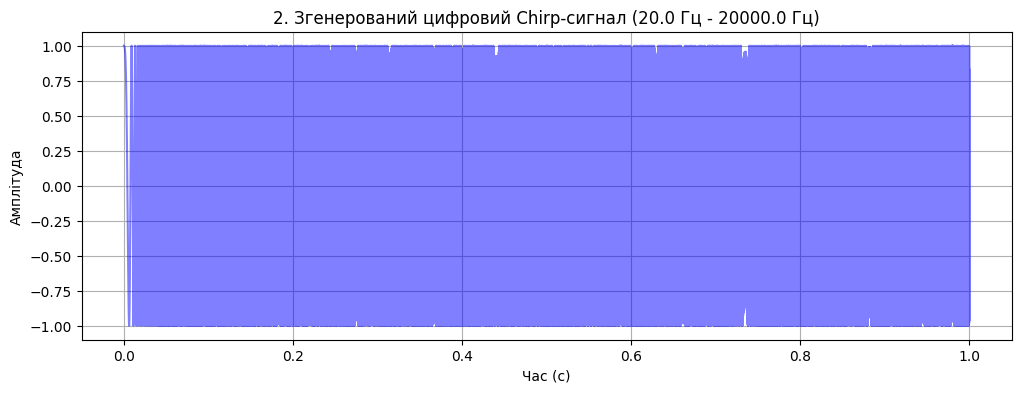

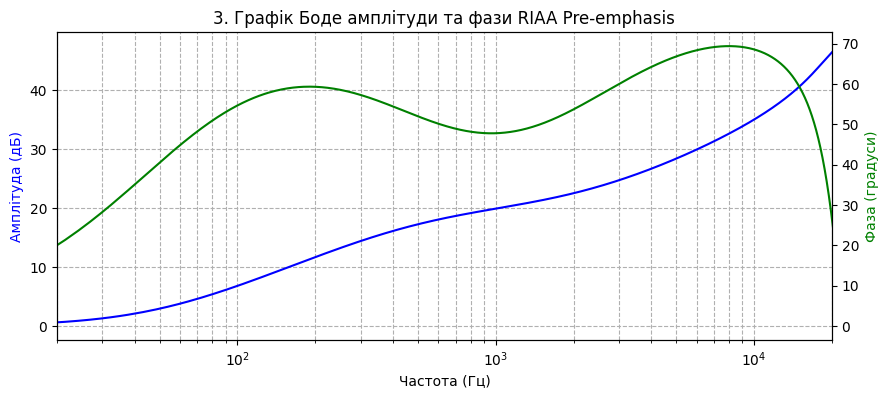

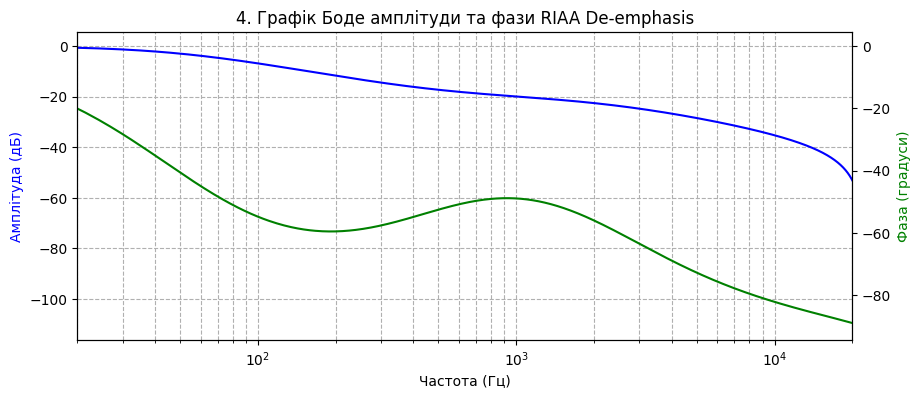

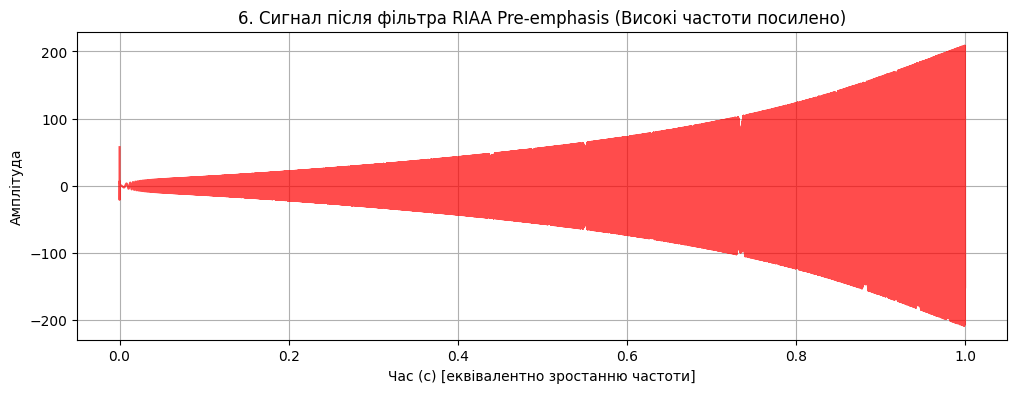

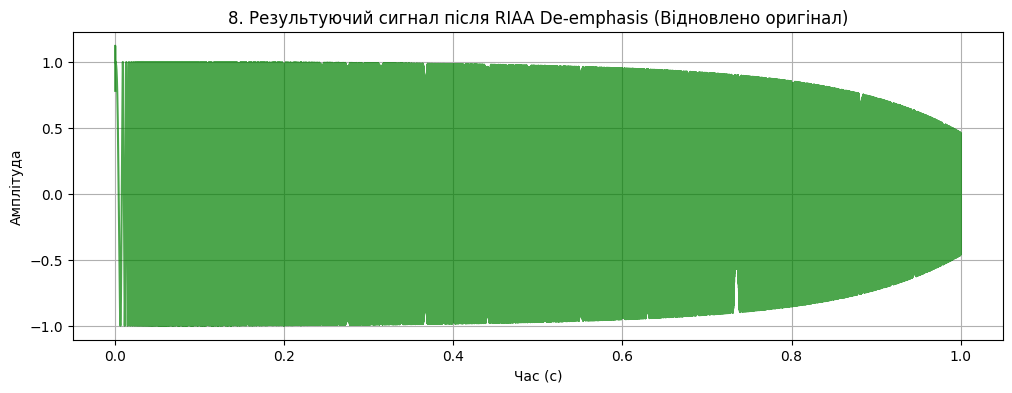

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# 1. Введення даних від користувача
print("--- Параметри аудіосигналу ---")
try:
    A_a = float(input("Введіть амплітуду A_a (наприклад, 1.0): ") or 1.0)
    f1 = float(input("Введіть початкову частоту f1 в Гц (наприклад, 20): ") or 20.0)
    f2 = float(input("Введіть кінцеву частоту f2 в Гц (наприклад, 20000): ") or 20000.0)
except ValueError:
    A_a, f1, f2 = 1.0, 20.0, 20000.0
    print("Помилка вводу. Використано стандартні значення: A_a=1.0, f1=20, f2=20000")

fs = 44100  # Стандартна частота дискретизації аудіо

# 2. Генерація та квантизація сигналу
# Створюємо масив часу (1 секунда)
t = np.linspace(0, 1, fs, endpoint=False)

# Генеруємо Chirp сигнал (частота лінійно зростає від f1 до f2)
audio_analog = A_a * signal.chirp(t, f0=f1, t1=1, f1=f2, method='linear')

# Квантизація 16 біт (переведення у дискретні рівні від -32768 до 32767)
max_int16 = 32767
audio_q = np.round(audio_analog * max_int16) / max_int16

plt.figure(figsize=(12, 4))
plt.plot(t, audio_q, color='blue', alpha=0.5)
plt.title(f'2. Згенерований цифровий Chirp-сигнал ({f1} Гц - {f2} Гц)')
plt.xlabel('Час (с)')
plt.ylabel('Амплітуда')
plt.grid(True)
plt.show()

# Підготовка фільтрів RIAA
# Стандартні постійні часу RIAA
t1 = 3180e-6
t2 = 318e-6
t3 = 75e-6
# Для оцифровки Pre-emphasis потрібен додатковий високочастотний полюс (щоб фільтр був реалізовним)
t4 = 3.18e-6 # Полюс на ~50 кГц

# Математичні коефіцієнти аналогових фільтрів
# De-emphasis (Відтворення)
num_de_c = [t2, 1]
den_de_c = [t1*t3, t1 + t3, 1]

# Pre-emphasis (Запис)
num_pre_c = [t1*t3, t1 + t3, 1]
den_pre_c = [t2*t4, t2 + t4, 1]

# Білінійне перетворення: Аналог (s-площина) -> Цифра (z-площина)
b_de, a_de = signal.bilinear(num_de_c, den_de_c, fs)
b_pre, a_pre = signal.bilinear(num_pre_c, den_pre_c, fs)

# Допоміжна функція для побудови графіків Боде
def plot_bode(b, a, title, step_num):
    w, h = signal.freqz(b, a, worN=8192, fs=fs)

    fig, ax1 = plt.subplots(figsize=(10, 4))
    ax1.set_title(f'{step_num}. {title}')

    # Графік амплітуди
    ax1.plot(w, 20 * np.log10(abs(h) + 1e-12), 'b')
    ax1.set_ylabel('Амплітуда (дБ)', color='b')
    ax1.set_xlabel('Частота (Гц)')
    ax1.set_xscale('log')
    ax1.set_xlim([20, 20000])
    ax1.grid(True, which="both", ls="--")

    # Графік фази
    ax2 = ax1.twinx()
    ax2.plot(w, np.unwrap(np.angle(h)) * 180 / np.pi, 'g')
    ax2.set_ylabel('Фаза (градуси)', color='g')
    plt.show()

# 3. Візуалізація графіка Боде Pre-emphasis
plot_bode(b_pre, a_pre, 'Графік Боде амплітуди та фази RIAA Pre-emphasis', 3)

# 4. Візуалізація графіка Боде De-emphasis
plot_bode(b_de, a_de, 'Графік Боде амплітуди та фази RIAA De-emphasis', 4)

# 5-6. Застосування Pre-emphasis та його візуалізація
signal_pre = signal.lfilter(b_pre, a_pre, audio_q)

plt.figure(figsize=(12, 4))
plt.plot(t, signal_pre, color='red', alpha=0.7)
plt.title('6. Сигнал після фільтра RIAA Pre-emphasis (Високі частоти посилено)')
plt.xlabel('Час (с) [еквівалентно зростанню частоти]')
plt.ylabel('Амплітуда')
plt.grid(True)
plt.show()

# 7-8. Застосування De-emphasis та його візуалізація
signal_de = signal.lfilter(b_de, a_de, signal_pre)

plt.figure(figsize=(12, 4))
plt.plot(t, signal_de, color='green', alpha=0.7)
plt.title('8. Результуючий сигнал після RIAA De-emphasis (Відновлено оригінал)')
plt.xlabel('Час (с)')
plt.ylabel('Амплітуда')
plt.grid(True)
plt.show()